# 05 — Anomaly Detection
**RetailMind · Data Science Practicum 2 · Sai Teja Sunku**

Three independent detectors combined into a single ranked list. **Every
flagged anomaly carries a `reason` string** — alerts without explanation
are noise, not signal.

| Detector | What it catches |
|---|---|
| IsolationForest (multivariate) | Subtle joint anomalies in the engineered feature space |
| STL residual z-score | Seasonally-adjusted outliers (handles weekly cycles) |
| IQR rule (per entity) | Robust, explainable baseline |


In [1]:
# Common setup: make the project package importable from the notebooks/ folder
import sys, warnings, json
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px


## 1. Run all three detectors

In [2]:
from retailmind import RetailPipeline

p = RetailPipeline.from_files('../train.csv', auxiliary_paths=['../store.csv'])
p.canonicalize_()
p.anomalies_(sample_entities=20)
print(f'{len(p.anomalies)} anomalies flagged across methods')
p.anomalies.head(10)

4936 anomalies flagged across methods


,entity_id,date,value,lower_bound,upper_bound,method,score,reason
0,262,2015-05-14,38367.0,NaN,NaN,stl_residual,7.965347,"STL residual z=8.0 (seasonally adjusted, expec..."
1,523,2013-05-20,0.0,NaN,NaN,stl_residual,7.173792,"STL residual z=-7.2 (seasonally adjusted, expe..."
2,817,2013-05-20,0.0,NaN,NaN,stl_residual,6.948298,"STL residual z=-6.9 (seasonally adjusted, expe..."
3,523,2013-04-01,0.0,NaN,NaN,stl_residual,6.920525,"STL residual z=-6.9 (seasonally adjusted, expe..."
4,262,2014-05-29,37403.0,NaN,NaN,stl_residual,6.845459,"STL residual z=6.8 (seasonally adjusted, expec..."
5,262,2013-03-29,36227.0,NaN,NaN,stl_residual,6.582217,"STL residual z=6.6 (seasonally adjusted, expec..."
6,262,2015-05-01,38484.0,NaN,NaN,stl_residual,6.537204,"STL residual z=6.5 (seasonally adjusted, expec..."
7,698,2015-04-06,0.0,NaN,NaN,stl_residual,6.464045,"STL residual z=-6.5 (seasonally adjusted, expe..."
8,817,2013-05-01,0.0,NaN,NaN,stl_residual,6.422732,"STL residual z=-6.4 (seasonally adjusted, expe..."
9,523,2013-03-29,0.0,NaN,NaN,stl_residual,6.310261,"STL residual z=-6.3 (seasonally adjusted, expe..."


## 2. Each anomaly explains itself

In [3]:
for _, r in p.anomalies.head(5).iterrows():
    print(f'  [{r["method"]:18s}] entity {r["entity_id"]} on {r["date"].date()}')
    print(f'      {r["reason"]}')
    print()

  [stl_residual      ] entity 262 on 2015-05-14
      STL residual z=8.0 (seasonally adjusted, expected≈18277)

  [stl_residual      ] entity 523 on 2013-05-20
      STL residual z=-7.2 (seasonally adjusted, expected≈21679)

  [stl_residual      ] entity 817 on 2013-05-20
      STL residual z=-6.9 (seasonally adjusted, expected≈30681)

  [stl_residual      ] entity 523 on 2013-04-01
      STL residual z=-6.9 (seasonally adjusted, expected≈20922)

  [stl_residual      ] entity 262 on 2014-05-29
      STL residual z=6.8 (seasonally adjusted, expected≈20103)



## 3. Visualise anomalies on the highest-scoring entity

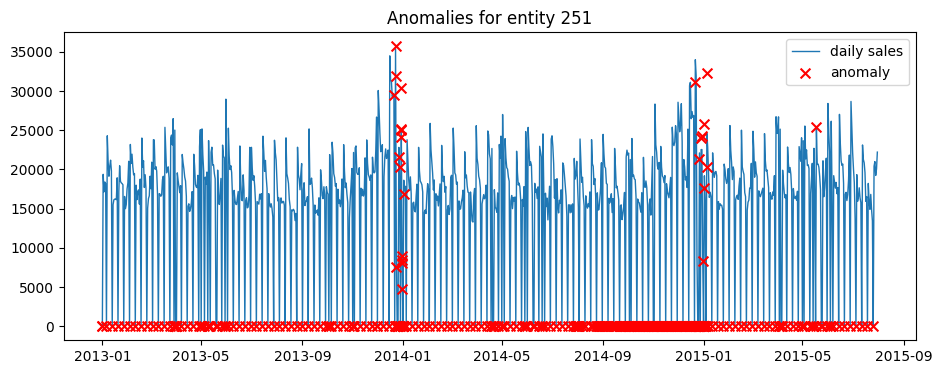

In [4]:
ent = p.anomalies['entity_id'].value_counts().idxmax()
series = p.canonical[p.canonical['entity_id'] == ent]
pts = p.anomalies[p.anomalies['entity_id'] == ent]

plt.figure(figsize=(11, 4))
plt.plot(series['date'], series['sales'], label='daily sales', linewidth=1)
plt.scatter(pts['date'], pts['value'], color='red', s=50, marker='x', label='anomaly', zorder=3)
plt.title(f'Anomalies for entity {ent}')
plt.legend(); plt.show()

## 4. Method breakdown

In [5]:
p.anomalies['method'].value_counts().to_frame('count')

,count
method,
isolation_forest,3660
iqr,809
stl_residual,467


## Summary
- Three detectors with different perspectives → robust to false positives
- Reason strings make every alert actionable
- Sorted by score so the user always sees the most significant first

**Next:** [06 — Sales Drivers (Regression)](06_regression_drivers.ipynb)
